# Extended corner plot of GW170817 (log e0 prior)

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import bilby
import pandas as pd
import numpy as np
import matplotlib.lines as mlines
import corner

In [2]:
# TaylorF2Ecck
result1 = bilby.result.read_in_result("../result_files/TF2Ecck_3PN_bayeswave_logprior.hdf5")
chirp_mass1 = result1.posterior["chirp_mass"].values
mass_ratio1 =  result1.posterior["mass_ratio"].values
e01 = result1.posterior["eccentricity"].values
theta_jn1 = result1.posterior["theta_jn"].values
D1 = result1.posterior["luminosity_distance"].values
ra1 = result1.posterior["ra"].values
dec1 = result1.posterior["dec"].values
m11 = (chirp_mass1*(1+mass_ratio1)**(1/5))/mass_ratio1**(3/5)
m21 = chirp_mass1*mass_ratio1**(2/5)*(1+mass_ratio1)**(1/5)
mtot1 = m11 + m21
eta1 = (m11*m21)/(mtot1**2)

# TaylorF2Ecc 3PN
result2 = bilby.result.read_in_result("../result_files/TF2Ecc_3PN_bayeswave_logprior.hdf5")
chirp_mass2 = result2.posterior["chirp_mass"].values
mass_ratio2 =  result2.posterior["mass_ratio"].values
e02 = result2.posterior["eccentricity"].values
theta_jn2 = result2.posterior["theta_jn"].values
D2 = result2.posterior["luminosity_distance"].values
ra2 = result2.posterior["ra"].values
dec2 = result2.posterior["dec"].values
m12 = (chirp_mass2*(1+mass_ratio2)**(1/5))/mass_ratio2**(3/5)
m22 = chirp_mass2*mass_ratio2**(2/5)*(1+mass_ratio2)**(1/5)
mtot2 = m12 + m22
eta2 = (m12*m22)/(mtot2**2)

# TaylorF2Ecc 3.5PN (no spin)
result3 = bilby.result.read_in_result("../result_files/TF2Ecc_3p5PN_bayeswave_logprior.hdf5")
chirp_mass3 = result3.posterior["chirp_mass"].values
mass_ratio3 =  result3.posterior["mass_ratio"].values
e03 = result3.posterior["eccentricity"].values
theta_jn3 = result3.posterior["theta_jn"].values
D3 = result3.posterior["luminosity_distance"].values
ra3 = result3.posterior["ra"].values
dec3 = result3.posterior["dec"].values
m13 = (chirp_mass3*(1+mass_ratio3)**(1/5))/mass_ratio3**(3/5)
m23 = chirp_mass3*mass_ratio3**(2/5)*(1+mass_ratio3)**(1/5)
mtot3 = m13 + m23
eta3 = (m13*m23)/(mtot3**2)

06:31 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
06:31 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
06:31 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


In [3]:
sigma = 100-90
mean1, median1, std1, upper_90percentile1, lower_90percentile1 = np.mean(e01), np.median(e01), np.std(e01), np.percentile(e01, 100-sigma/2), np.percentile(e01, sigma/2)
mean2, median2, std2, upper_90percentile2, lower_90percentile2 = np.mean(e02), np.median(e02), np.std(e02), np.percentile(e02, 100-sigma/2), np.percentile(e02, sigma/2)
mean3, median3, std3, upper_90percentile3, lower_90percentile3 = np.mean(e03), np.median(e03), np.std(e03), np.percentile(e03, 100-sigma/2), np.percentile(e03, sigma/2)
print(f"TaylorF2Ecck3PN: mean={mean1:.4f}, median={median1:.4f}, upper_90percentile={upper_90percentile1:.4f}, lower_90percentile={lower_90percentile1:.4f}")
print(f"TaylorF2Ecc3PN: mean={mean2:.4f}, median={median2:.4f}, upper_90percentile={upper_90percentile2:.4f}, lower_90percentile={lower_90percentile2:.4f}")
print(f"TaylorF2Ecc3p5PN: mean={mean3:.4f}, median={median3:.4f}, upper_90percentile={upper_90percentile3:.4f}, lower_90percentile={lower_90percentile3:.4f}")

TaylorF2Ecck3PN: mean=0.0059, median=0.0047, upper_90percentile=0.0143, lower_90percentile=0.0012
TaylorF2Ecc3PN: mean=0.0056, median=0.0043, upper_90percentile=0.0137, lower_90percentile=0.0012
TaylorF2Ecc3p5PN: mean=0.0044, median=0.0034, upper_90percentile=0.0110, lower_90percentile=0.0011


In [4]:
print(f"TaylorF2Ecck3PN e0: {median1:.3f}^+{upper_90percentile1-median1:.3f}_-{median1-lower_90percentile1:.3f}")
print(f"TaylorF2Ecc3PN e0: {median2:.3f}^+{upper_90percentile2-median2:.3f}_-{median2-lower_90percentile2:.3f}")
print(f"TaylorF2Ecc3p5PN e0: {median3:.3f}^+{upper_90percentile3-median3:.3f}_-{median3-lower_90percentile3:.3f}")

TaylorF2Ecck3PN e0: 0.005^+0.010_-0.003
TaylorF2Ecc3PN e0: 0.004^+0.009_-0.003
TaylorF2Ecc3p5PN e0: 0.003^+0.008_-0.002


In [5]:
rng = np.random.default_rng(12345)
nsamples = np.min([len(chirp_mass1), len(chirp_mass2), len(chirp_mass3)])
data1 = np.transpose(np.array([chirp_mass1, mass_ratio1, mtot1, eta1, e01, D1, theta_jn1]))
df1 = pd.DataFrame(data1, columns=["chirp_mass", "mass_ratio", 'mtot', 'eta', "eccentricity", "luminosity_distance", "theta_jn"])
df1 = df1.sample(n=nsamples, random_state=rng)

data2 = np.transpose(np.array([chirp_mass2, mass_ratio2, mtot2, eta2, e02, D2, theta_jn2]))
df2 = pd.DataFrame(data2, columns=["chirp_mass", "mass_ratio", 'mtot', 'eta', "eccentricity", "luminosity_distance", "theta_jn"])
df2 = df2.sample(n=nsamples, random_state=rng)

data3 = np.transpose(np.array([chirp_mass3, mass_ratio3, mtot3, eta3, e03, D3, theta_jn3]))
df3 = pd.DataFrame(data3, columns=["chirp_mass", "mass_ratio", 'mtot', 'eta', "eccentricity", "luminosity_distance", "theta_jn"])
df3 = df3.sample(n=nsamples, random_state=rng)

In [6]:
# log10BF values
log10BF1 = result1.log_10_bayes_factor
log10BF2 = result2.log_10_bayes_factor
log10BF3 = result3.log_10_bayes_factor
print(f"TaylorF2Ecck3PN log10BF: {log10BF1:.2f}")
print(f"TaylorF2Ecc3PN log10BF: {log10BF2:.2f}")
print(f"TaylorF2Ecc3p5PN log10BF: {log10BF3:.2f}")

TaylorF2Ecck3PN log10BF: 220.84
TaylorF2Ecc3PN log10BF: 220.76
TaylorF2Ecc3p5PN log10BF: 221.29


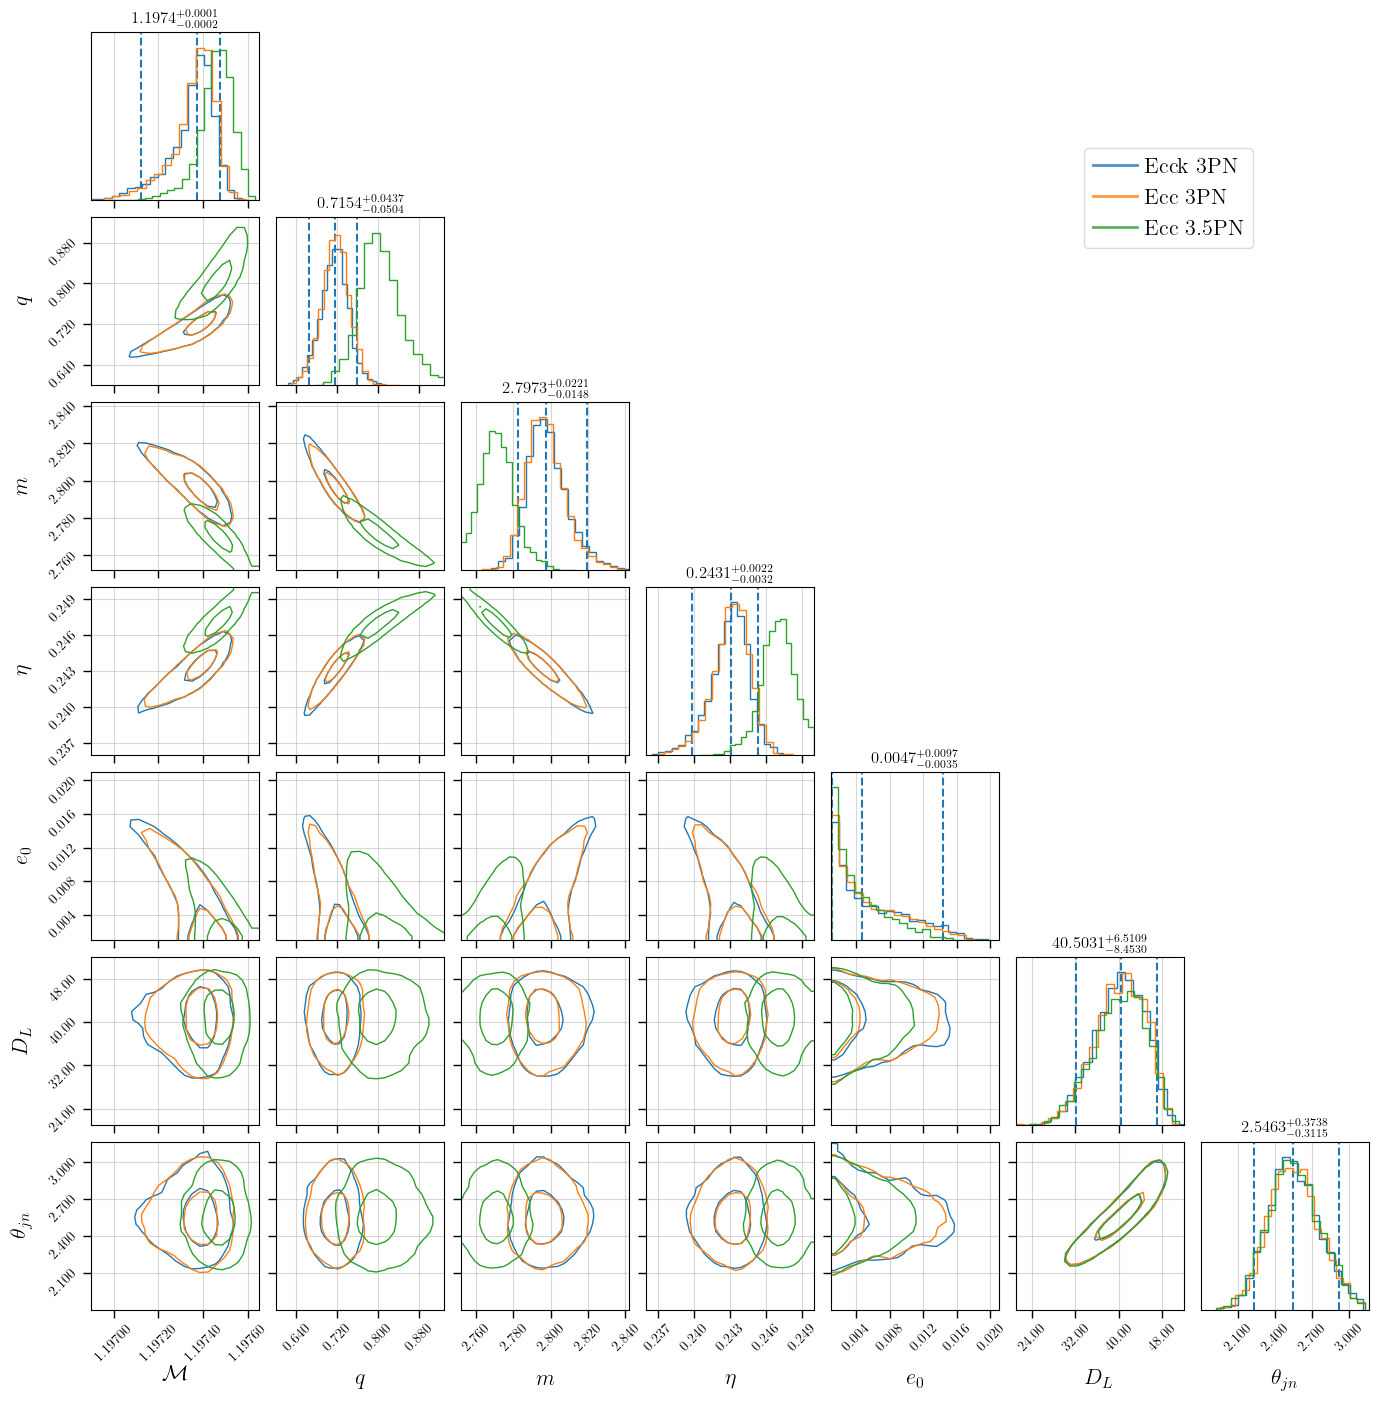

In [7]:
ndim = 7
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})
fig, axes = plt.subplots(ndim, ndim, figsize=(14, 14), gridspec_kw={"hspace": 0.1, "wspace": 0.1})

corner.corner(df1, fig=fig,color = 'C0', bins=20, smooth=0.8, plot_datapoints=False, plot_density=False, contourf_kwargs= dict(alpha=0.4), levels=(0.393,0.864), hist_kwargs={'linewidth': 1}, contour_kwargs={'linewidths': 1}, show_titles=True, quantiles=(0.05, 0.5, 0.95), title_fmt='.4f', title_kwargs={'fontsize': 12}, label_kwargs={'fontsize': 16})

corner.corner(df2, fig=fig, color='C1', bins=20, smooth=0.8, plot_datapoints=False, plot_density=False, contourf_kwargs= dict(alpha=0.4), levels=(0.393,0.864), hist_kwargs={'linewidth': 1}, contour_kwargs={'linewidths': 1},)

corner.corner(df3, fig=fig, color='C2', bins=20, smooth=0.8, plot_datapoints=False, plot_density=False, contourf_kwargs= dict(alpha=0.4), levels=(0.393,0.864), hist_kwargs={'linewidth': 1}, contour_kwargs={'linewidths': 1})

for i in range(ndim):
    title = axes[i, i].get_title()
    if " = " in title:
        axes[i, i].set_title(title.split(" = ", 1)[1], fontsize=12)

# x-axis tick labels
# Mc
axes[6, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.5f' % x))
min_mc = 1.19690
max_mc = 1.19765
axes[6,0].set_xlim(min_mc, max_mc)
axes[5,0].set_xlim(min_mc, max_mc)
axes[4,0].set_xlim(min_mc, max_mc)
axes[3,0].set_xlim(min_mc, max_mc)
axes[2,0].set_xlim(min_mc, max_mc)
axes[1,0].set_xlim(min_mc, max_mc)
axes[0,0].set_xlim(min_mc, max_mc)
# q
axes[6, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
min_q = 0.60
max_q = 0.93
axes[6,1].set_xlim(min_q, max_q)
axes[5,1].set_xlim(min_q, max_q)
axes[4,1].set_xlim(min_q, max_q)
axes[3,1].set_xlim(min_q, max_q)
axes[2,1].set_xlim(min_q, max_q)
axes[1,1].set_xlim(min_q, max_q)
# m
axes[6, 2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
min_m = 2.752
max_m = 2.842
axes[6,2].set_xlim(min_m, max_m)
axes[5,2].set_xlim(min_m, max_m)
axes[4,2].set_xlim(min_m, max_m)
axes[3,2].set_xlim(min_m, max_m)
axes[2,2].set_xlim(min_m, max_m)
# eta
axes[6, 3].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
min_eta = 0.236
max_eta = 0.250
axes[6,3].set_xlim(min_eta, max_eta)
axes[5,3].set_xlim(min_eta, max_eta)
axes[4,3].set_xlim(min_eta, max_eta)
axes[3,3].set_xlim(min_eta, max_eta)
axes[3,3].set_xlim(min_eta, max_eta)
# e0
axes[6, 4].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
min_e0 = 0.001
max_e0 = 0.021
axes[6,4].set_xlim(min_e0, max_e0)
axes[5,4].set_xlim(min_e0, max_e0)
axes[4,4].set_xlim(min_e0, max_e0)
# dl
axes[6, 5].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.2f' % x))
min_dl = 21.
max_dl = 52.
axes[6,5].set_xlim(min_dl, max_dl)
axes[5,5].set_xlim(min_dl, max_dl)
# theta_jn
min_theta_jn = 1.8
max_theta_jn = 3.16
axes[6, 6].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
axes[6,6].set_xlim(min_theta_jn, max_theta_jn)

# y-axis tick labels
axes[6, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '%.3f' % y))
axes[6,0].set_ylim(min_theta_jn, max_theta_jn)
axes[6,1].set_ylim(min_theta_jn, max_theta_jn)
axes[6,2].set_ylim(min_theta_jn, max_theta_jn)
axes[6,3].set_ylim(min_theta_jn, max_theta_jn)
axes[6,4].set_ylim(min_theta_jn, max_theta_jn)
axes[6,5].set_ylim(min_theta_jn, max_theta_jn)
axes[5, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '%.2f' % y))
axes[5,0].set_ylim(min_dl, max_dl)
axes[5,1].set_ylim(min_dl, max_dl)
axes[5,2].set_ylim(min_dl, max_dl)
axes[5,3].set_ylim(min_dl, max_dl)
axes[5,4].set_ylim(min_dl, max_dl)
axes[4, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '%.3f' % y))
axes[4,0].set_ylim(min_e0, max_e0)
axes[4,1].set_ylim(min_e0, max_e0)
axes[4,2].set_ylim(min_e0, max_e0)
axes[4,3].set_ylim(min_e0, max_e0)
axes[3, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '%.3f' % y))
axes[3,0].set_ylim(min_eta, max_eta)
axes[3,1].set_ylim(min_eta, max_eta)
axes[3,2].set_ylim(min_eta, max_eta)
axes[2, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '%.3f' % y))
axes[2,0].set_ylim(min_m, max_m)
axes[2,1].set_ylim(min_m, max_m)
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '%.3f' % y))
axes[1,0].set_ylim(min_q, max_q)

# x-axis labels
size_axis_label = 16
axes[6,0].set_xlabel(r'$\mathcal{M}$', labelpad=2, fontsize=size_axis_label)
axes[6,1].set_xlabel(r'$q$', labelpad=11, fontsize=size_axis_label)
axes[6,2].set_xlabel(r'$m$', labelpad=11, fontsize=size_axis_label)
axes[6,3].set_xlabel(r'$\eta$', labelpad=11, fontsize=size_axis_label)
axes[6,4].set_xlabel(r'$e_0$', labelpad=11, fontsize=size_axis_label)
axes[6,5].set_xlabel(r'$D_L$', labelpad=11, fontsize=size_axis_label)
axes[6,6].set_xlabel(r'$\theta_{jn}$', labelpad=11, fontsize=size_axis_label)
# y-axis labels
axes[6, 0].set_ylabel(r'$\theta_{jn}$', labelpad=11, fontsize=size_axis_label)
axes[5, 0].set_ylabel(r'$D_L$', labelpad=11, fontsize=size_axis_label)
axes[4, 0].set_ylabel(r'$e_0$', labelpad=11, fontsize=size_axis_label)
axes[3, 0].set_ylabel(r'$\eta$', labelpad=11, fontsize=size_axis_label)
axes[2, 0].set_ylabel(r'$m$', labelpad=11, fontsize=size_axis_label)
axes[1, 0].set_ylabel(r'$q$', labelpad=11, fontsize=size_axis_label)

# add grid
for i in range(ndim):
    for j in range(ndim):
        if axes[i, j] is not None:
            axes[i, j].grid(True, which="both", ls="-", alpha=0.5)

# add legend with line colors
blue_line = mlines.Line2D([], [], color='C0', label='Ecck 3PN')
orange_line = mlines.Line2D([], [], color='C1', label='Ecc 3PN')
green_line = mlines.Line2D([], [], color='C2', label='Ecc 3.5PN')
handles = [blue_line, orange_line, green_line]
labels = [h.get_label() for h in handles] 
#fig.legend(handles=handles, labels=labels, bbox_to_anchor=(0., 0.9, 0.9, .0), ncol=1, fontsize=16)
legend = fig.legend(handles=handles, labels=labels, handlelength=2, loc='upper right', bbox_to_anchor=(0., 0.9, 0.9, .0), frameon=True, fontsize=16, edgecolor='lightgray')
# # rounded box for legend
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
# Modify line width for legend entries
for handle in legend.get_lines():
    handle.set_linewidth(2)
    handle.set_alpha(0.8)

plt.savefig("fullpe_gw170817_logprior.pdf", bbox_inches="tight", dpi=300)
plt.show()